# A03 Routing Diagnostics

This notebook combines expert usage, entropy, stage consistency, and feature-bucket routing patterns into one diagnostic figure.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

RESULTS_ROOT = Path("/workspace/FeaturedMoE/writing/results")
if str(RESULTS_ROOT) not in sys.path:
    sys.path.insert(0, str(RESULTS_ROOT))

from _shared.io_helpers import export_figure, load_csv_or_demo
from _shared.paper_theme import set_paper_theme
from _shared.plot_builders import (
    grouped_barplot,
    heatmap_from_long,
    lineplot_with_markers,
    scatterplot_with_annotations,
)

set_paper_theme(context="notebook")

USAGE_PATH = RESULTS_ROOT / "A03_routing_diagnostics/A03a_expert_usage.csv"
ENTROPY_PATH = RESULTS_ROOT / "A03_routing_diagnostics/A03b_entropy_effective_experts.csv"
CONSISTENCY_PATH = RESULTS_ROOT / "A03_routing_diagnostics/A03c_stage_consistency.csv"
FEATURE_PATH = RESULTS_ROOT / "A03_routing_diagnostics/A03d_feature_bucket_patterns.csv"

USAGE_COLUMNS = ["paper_section", "panel", "dataset", "stage", "variant_or_model", "expert_id", "group_id", "usage_weight", "usage_rank", "run_id", "source_path", "notes"]
ENTROPY_COLUMNS = ["paper_section", "panel", "dataset", "stage", "variant_or_model", "measure", "value", "run_id", "source_path", "notes"]
CONSISTENCY_COLUMNS = ["paper_section", "panel", "dataset", "stage", "variant_or_model", "similarity_bucket", "consistency_value", "run_id", "source_path", "notes"]
FEATURE_COLUMNS = ["paper_section", "panel", "dataset", "stage", "variant_or_model", "feature_family", "bucket_label", "expert_id", "route_weight", "run_id", "source_path", "notes"]


def demo_usage() -> pd.DataFrame:
    rows = []
    for stage, weights in {"macro": [0.12, 0.14, 0.11, 0.13], "mid": [0.18, 0.24, 0.20, 0.19], "micro": [0.26, 0.31, 0.24, 0.19]}.items():
        for expert_id, weight in enumerate(weights, start=1):
            rows.append({
                "paper_section": "A03_routing_diagnostics",
                "panel": "usage",
                "dataset": "KuaiRec",
                "stage": stage,
                "variant_or_model": "RouteRec",
                "expert_id": expert_id,
                "group_id": 1 if expert_id <= 2 else 2,
                "usage_weight": weight,
                "usage_rank": expert_id,
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            })
    return pd.DataFrame(rows)


def demo_entropy() -> pd.DataFrame:
    rows = []
    values = [("macro", "entropy", 1.72), ("macro", "effective_experts", 3.4), ("mid", "entropy", 1.41), ("mid", "effective_experts", 2.8), ("micro", "entropy", 1.12), ("micro", "effective_experts", 2.2)]
    for stage, measure, value in values:
        rows.append({
            "paper_section": "A03_routing_diagnostics",
            "panel": "entropy",
            "dataset": "KuaiRec",
            "stage": stage,
            "variant_or_model": "RouteRec",
            "measure": measure,
            "value": value,
            "run_id": "demo",
            "source_path": "demo",
            "notes": "demo data",
        })
    return pd.DataFrame(rows)


def demo_consistency() -> pd.DataFrame:
    rows = []
    buckets = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
    curves = {
        "macro": [0.45, 0.54, 0.63, 0.71, 0.77],
        "mid": [0.39, 0.47, 0.56, 0.64, 0.71],
        "micro": [0.28, 0.35, 0.44, 0.53, 0.61],
    }
    for stage, values in curves.items():
        for bucket, value in zip(buckets, values):
            rows.append({
                "paper_section": "A03_routing_diagnostics",
                "panel": "consistency",
                "dataset": "KuaiRec",
                "stage": stage,
                "variant_or_model": "RouteRec",
                "similarity_bucket": bucket,
                "consistency_value": value,
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            })
    return pd.DataFrame(rows)


def demo_feature_patterns() -> pd.DataFrame:
    rows = []
    feature_families = ["Tempo", "Focus", "Memory", "Exposure"]
    bucket_labels = ["low", "mid", "high"]
    for family_index, feature_family in enumerate(feature_families, start=1):
        for bucket_index, bucket_label in enumerate(bucket_labels, start=1):
            rows.append({
                "paper_section": "A03_routing_diagnostics",
                "panel": "feature_patterns",
                "dataset": "KuaiRec",
                "stage": "micro",
                "variant_or_model": "RouteRec",
                "feature_family": feature_family,
                "bucket_label": bucket_label,
                "expert_id": family_index,
                "route_weight": 0.12 + 0.05 * bucket_index + 0.03 * family_index,
                "run_id": "demo",
                "source_path": "demo",
                "notes": "demo data",
            })
    return pd.DataFrame(rows)


In [2]:
usage_df, usage_mode = load_csv_or_demo(USAGE_PATH, USAGE_COLUMNS, demo_builder=demo_usage)
entropy_df, entropy_mode = load_csv_or_demo(ENTROPY_PATH, ENTROPY_COLUMNS, demo_builder=demo_entropy)
consistency_df, consistency_mode = load_csv_or_demo(CONSISTENCY_PATH, CONSISTENCY_COLUMNS, demo_builder=demo_consistency)
feature_df, feature_mode = load_csv_or_demo(FEATURE_PATH, FEATURE_COLUMNS, demo_builder=demo_feature_patterns)
display(Markdown(f"**Load mode:** usage={usage_mode}, entropy={entropy_mode}, consistency={consistency_mode}, feature={feature_mode}"))


**Load mode:** usage=demo, entropy=demo, consistency=demo, feature=demo

Saved figures: /workspace/FeaturedMoE/writing/results/generated_figures/A03_routing_diagnostics.png, /workspace/FeaturedMoE/writing/results/generated_figures/A03_routing_diagnostics.pdf

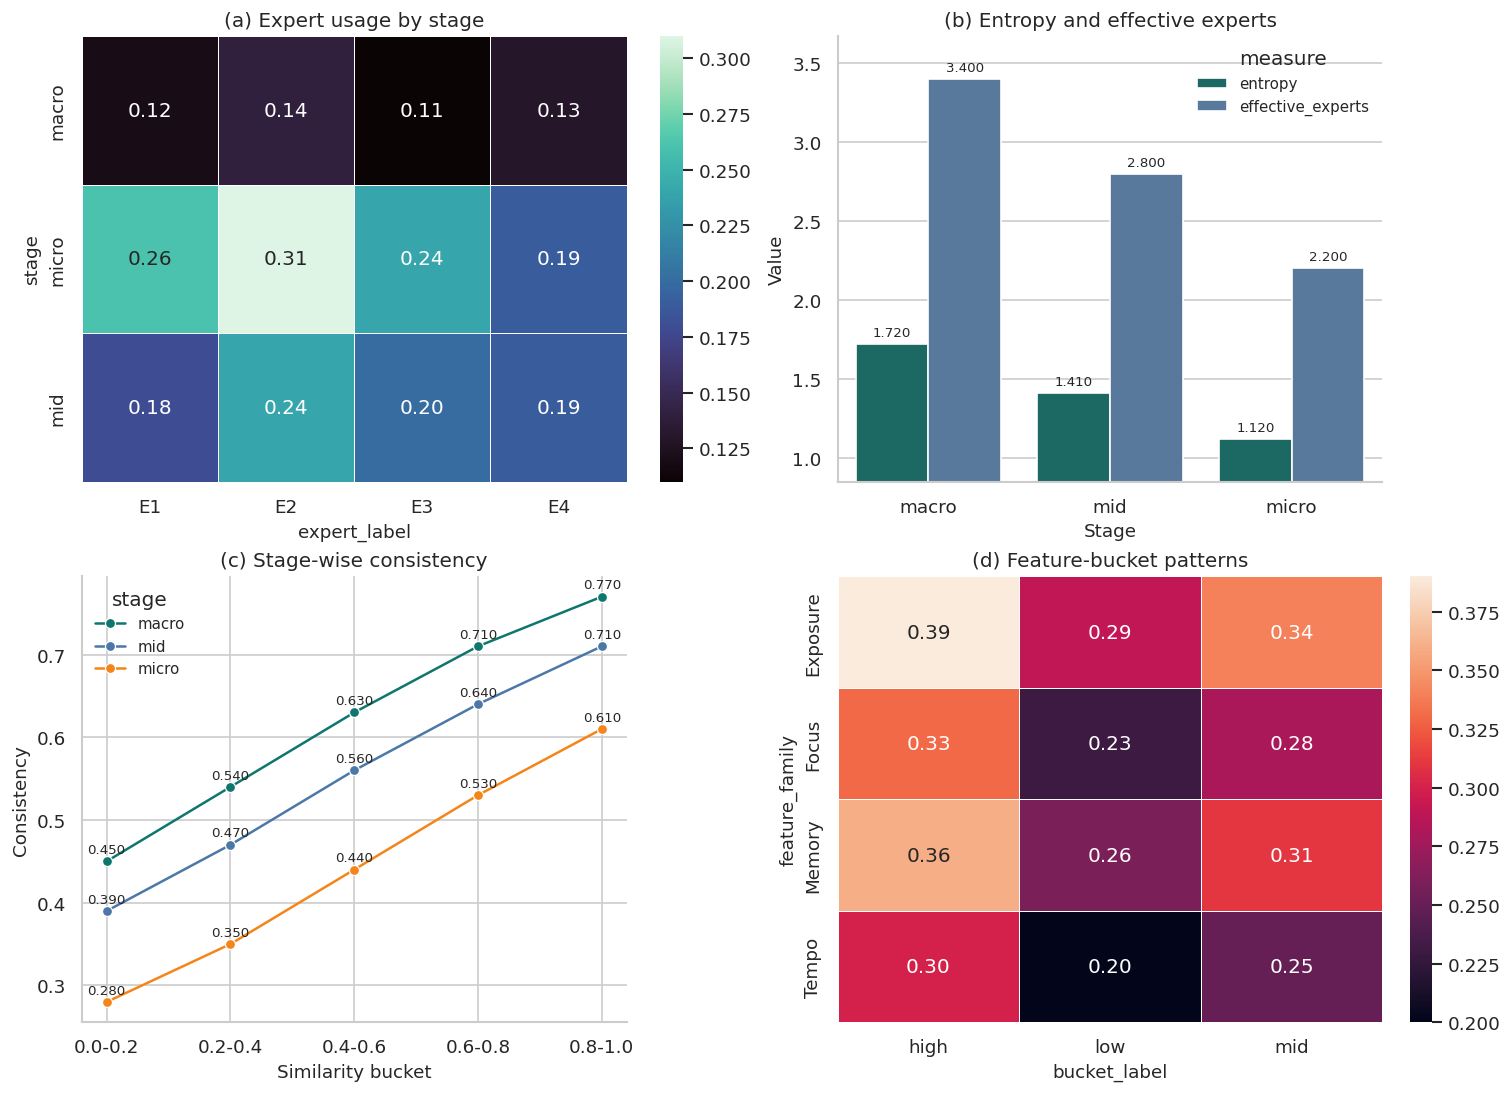

In [3]:
usage_heatmap = usage_df.copy()
usage_heatmap["expert_label"] = "E" + usage_heatmap["expert_id"].astype(str)

entropy_plot = entropy_df.copy()
entropy_plot["series"] = entropy_plot["stage"] + "-" + entropy_plot["measure"]

bucket_order = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]
consistency_df = consistency_df.copy()
consistency_df["similarity_bucket"] = pd.Categorical(consistency_df["similarity_bucket"], categories=bucket_order, ordered=True)
consistency_df = consistency_df.sort_values("similarity_bucket")

feature_heatmap = feature_df.copy()
feature_heatmap["family_bucket"] = feature_heatmap["feature_family"] + "-" + feature_heatmap["bucket_label"]

fig, axes = plt.subplots(2, 2, figsize=(12.5, 9), constrained_layout=True)
heatmap_from_long(usage_heatmap, index="stage", columns="expert_label", values="usage_weight", ax=axes[0, 0], title="(a) Expert usage by stage", cmap="mako", fmt=".2f")
grouped_barplot(entropy_plot, x="stage", hue="measure", y="value", ax=axes[0, 1], title="(b) Entropy and effective experts", ylabel="Value", xlabel="Stage")
lineplot_with_markers(consistency_df, x="similarity_bucket", y="consistency_value", hue="stage", ax=axes[1, 0], title="(c) Stage-wise consistency", ylabel="Consistency", xlabel="Similarity bucket", annotate_points=True)
heatmap_from_long(feature_heatmap, index="feature_family", columns="bucket_label", values="route_weight", ax=axes[1, 1], title="(d) Feature-bucket patterns", cmap="rocket", fmt=".2f")
saved_paths = export_figure(fig, "A03_routing_diagnostics", RESULTS_ROOT)
display(Markdown("Saved figures: " + ", ".join(str(path) for path in saved_paths)))
plt.show()
